In [1]:
pip install opencv-python matplotlib


Note: you may need to restart the kernel to use updated packages.


# Ex. 1

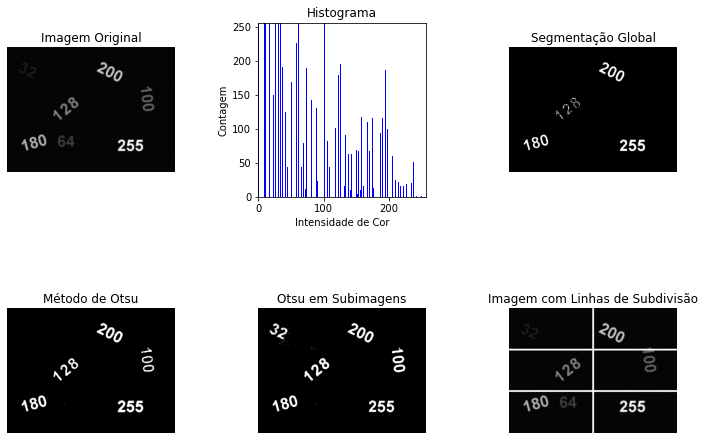

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("threshold.png", cv2.IMREAD_GRAYSCALE)

height, width = image.shape

third_height = height // 3
half_width = width // 2

fig, ax = plt.subplots(2, 3, figsize=(12, 8))
plt.subplots_adjust(wspace=0.5, hspace=0.5)

# a - Imagem original
ax[0, 0].set_title("Imagem Original")
ax[0, 0].imshow(image, cmap='gray')
ax[0, 0].axis("off")

# b - Histograma da imagem
ax[0, 1].set_title("Histograma")
ax[0, 1].hist(image.ravel(), bins=256, range=(0, 256), color="blue") 
ax[0, 1].set_xlim(0, 256)
ax[0, 1].set_ylim(0, 256)
ax[0, 1].set_xlabel("Intensidade de Cor")
ax[0, 1].set_ylabel("Contagem")

# c - Segmentação usando limiarização global
_, threshold_global = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY)
ax[0, 2].set_title("Segmentação Global")
ax[0, 2].imshow(threshold_global, cmap='gray')
ax[0, 2].axis("off")

# d - Segmentação usando o método de Otsu
_, threshold_otsu = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
ax[1, 0].set_title("Método de Otsu")
ax[1, 0].imshow(threshold_otsu, cmap='gray')
ax[1, 0].axis("off")

# Subdividindo a imagem em 6 partes iguais
subimages = [
    image[0:third_height, 0:half_width],
    image[0:third_height, half_width:],
    image[third_height:2 * third_height, 0:half_width],
    image[third_height:2 * third_height, half_width:],
    image[2 * third_height:, 0:half_width],
    image[2 * third_height:, half_width:],
]

# Aplicar Otsu individualmente em cada subimagem
sub_thresholds = []
for subimage in subimages:
    _, sub_threshold = cv2.threshold(subimage, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    sub_thresholds.append(sub_threshold)

# Combinando as subimagens após Otsu
result = np.zeros_like(image)
result[0:third_height, 0:half_width] = sub_thresholds[0]
result[0:third_height, half_width:] = sub_thresholds[1]
result[third_height:2 * third_height, 0:half_width] = sub_thresholds[2]
result[third_height:2 * third_height, half_width:] = sub_thresholds[3]
result[2 * third_height:, 0:half_width] = sub_thresholds[4]
result[2 * third_height:, half_width:] = sub_thresholds[5]

# Imagem com linhas de subdivisão
image_with_lines = np.copy(image)
color = (255, 255, 255)
thickness = 3

# Adicionando as linhas de subdivisão
cv2.line(image_with_lines, (0, third_height), (width, third_height), color, thickness)
cv2.line(image_with_lines, (0, 2 * third_height), (width, 2 * third_height), color, thickness)
cv2.line(image_with_lines, (half_width, 0), (half_width, height), color, thickness)

# e - Exibir a imagem com subdivisões
ax[1, 2].set_title("Imagem com Linhas de Subdivisão")
ax[1, 2].imshow(image_with_lines, cmap='gray')
ax[1, 2].axis("off")

# f - Imagem resultante após aplicação de Otsu em subimagens
ax[1, 1].set_title("Otsu em Subimagens")
ax[1, 1].imshow(result, cmap='gray')
ax[1, 1].axis("off")

plt.show()


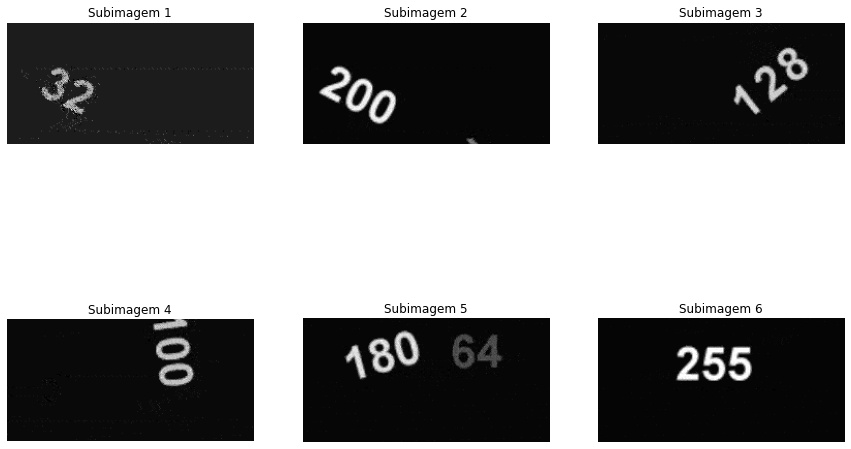

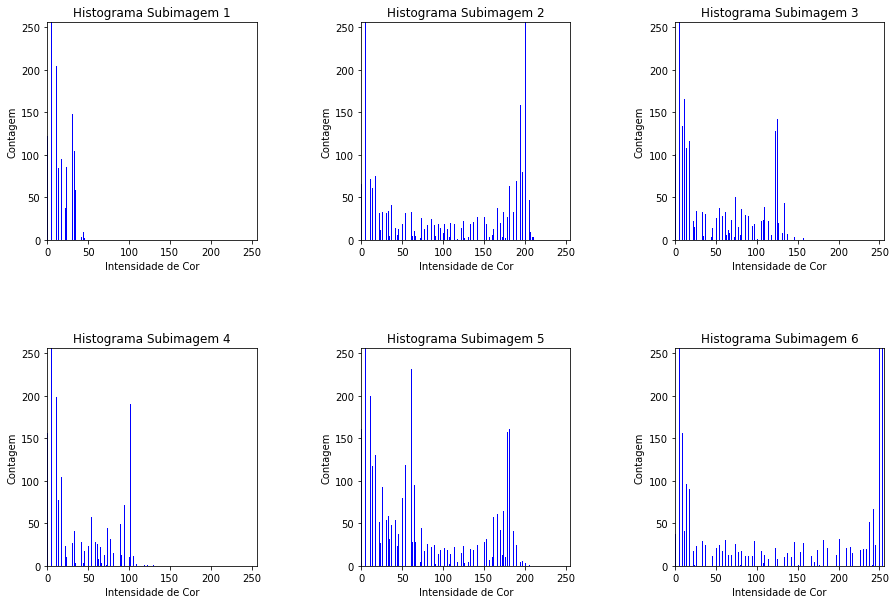

In [2]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))

ax[0, 0].set_title("Subimagem 1")
ax[0, 0].imshow(subimages[0], cmap='gray')
ax[0, 0].axis("off")

ax[0, 1].set_title("Subimagem 2")
ax[0, 1].imshow(subimages[1], cmap='gray')
ax[0, 1].axis("off")

ax[0, 2].set_title("Subimagem 3")
ax[0, 2].imshow(subimages[2], cmap='gray')
ax[0, 2].axis("off")

ax[1, 0].set_title("Subimagem 4")
ax[1, 0].imshow(subimages[3], cmap='gray')
ax[1, 0].axis("off")

ax[1, 1].set_title("Subimagem 5")
ax[1, 1].imshow(subimages[4], cmap='gray')
ax[1, 1].axis("off")

ax[1, 2].set_title("Subimagem 6")
ax[1, 2].imshow(subimages[5], cmap='gray')
ax[1, 2].axis("off")

fig, ax = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(wspace=0.5, hspace=0.5)

for i, subplot in enumerate(ax.flat):
    subplot.set_title(f"Histograma Subimagem {i+1}")
    subplot.hist(subimages[i].ravel(), bins=256, range=(0, 256), color="blue")
    subplot.set_xlim(0, 256)
    subplot.set_ylim(0, 256)
    subplot.set_xlabel("Intensidade de Cor")
    subplot.set_ylabel("Contagem")

plt.show()

# Ex. 2

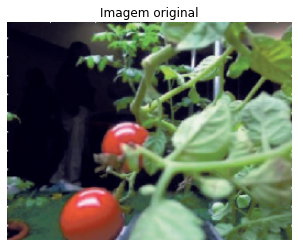

C:\Users\Vitor\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


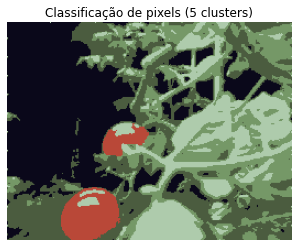

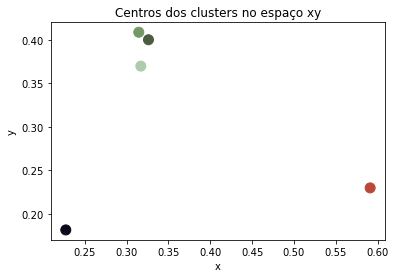

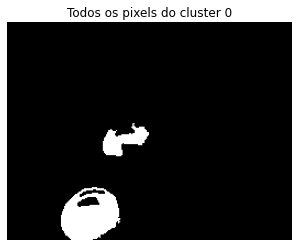

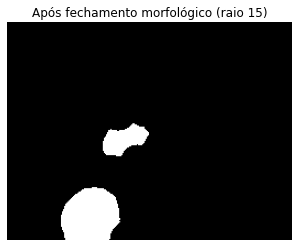

In [3]:
from sklearn.cluster import KMeans
from skimage.morphology import closing, disk

image_path = 'tomato.png'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Exibir a imagem original
plt.imshow(image)
plt.title("Imagem original")
plt.axis("off")
plt.show()
# array de pixels RGB
pixels = image.reshape((-1, 3))

n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(pixels)
cluster_centers = kmeans.cluster_centers_.astype(int)
labels = kmeans.labels_
segmented_image = cluster_centers[labels].reshape(image.shape)

plt.imshow(segmented_image)
plt.title("Classificação de pixels (5 clusters)")
plt.axis("off")
plt.show()

def rgb_(rgb):
    r, g, b = rgb / np.sum(rgb)
    x = r / (r + g + b)
    y = g / (r + g + b)
    return np.array([x, y])

xy_coords = np.array([rgb_(center) for center in cluster_centers])

plt.scatter(xy_coords[:, 0], xy_coords[:, 1], c=[tuple(center/255) for center in cluster_centers], s=100)
plt.xlabel('x')
plt.ylabel('y')
plt.title("Centros dos clusters no espaço xy")
plt.show()

# Criar uma máscara para todos os pixels do cluster 0
cluster_0_ = (labels == 0).reshape(image.shape[:2])

plt.imshow(cluster_0_, cmap='gray')
plt.title("Todos os pixels do cluster 0")
plt.axis("off")
plt.show()

# Aplicar fechamento morfológico com elemento circular de raio 15
closing_element = disk(15)
closed_mask = closing(cluster_0_, closing_element)

plt.imshow(closed_mask, cmap='gray')
plt.title("Após fechamento morfológico (raio 15)")
plt.axis("off")
plt.show()


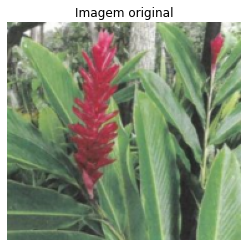

C:\Users\Vitor\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


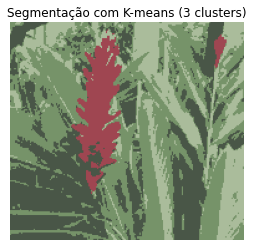

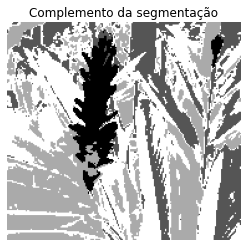

In [4]:
image_path = 'flowers.png'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Imagem original")
plt.axis("off")
plt.show()

pixels = image.reshape((-1, 3))
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(pixels)
cluster_centers = kmeans.cluster_centers_.astype(int)
labels = kmeans.labels_

segmented_image = cluster_centers[labels].reshape(image.shape)
plt.imshow(segmented_image)
plt.title("Segmentação com K-means (3 clusters)")
plt.axis("off")
plt.show()

# Criar uma máscara para a imagem segmentada
segmented_mask = (labels.reshape(image.shape[:2]))

# Criar o complemento da segmentação
complementary_image = np.invert(segmented_mask.astype(np.uint8))
plt.imshow(complementary_image, cmap='gray')
plt.title("Complemento da segmentação")
plt.axis("off")
plt.show()

In [7]:
pixels.shape

(32900, 3)